# 05 — Building and Training a Simple GAN

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a GAN from scratch: generator + discriminator
- Understand the adversarial training loop in detail (this is the formal GAN lesson the earlier examples previewed)
- Train on a 2-D toy problem where you can *see* the distributions match
- Train on MNIST and generate digit images from pure noise

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 5, lesson 04 "Simple GAN Experiment" — the same adversarial loop you ran in Keras, rewritten with the PyTorch training loop of Course 08 (AIAT 122) — Unit 1 and pushed to real images.

**Used later in:** Course 10 — Unit 1, lessons 06-09 (conditioning, StyleGAN, stabilisation, comparison) and Unit 5, lesson 04.

---

This notebook covers practical activities from **Course 10, Unit 1**:
- Building and training a simple GAN using PyTorch

---

## Introduction

A **GAN** trains two networks against each other:

- the **Generator G**: noise z → fake sample, trying to make fakes indistinguishable from data;
- the **Discriminator D**: sample → probability it is real, trying to catch the fakes.


## The Adversarial Training Loop, Step by Step

Every batch runs **two separate updates**:

**1. Discriminator step** — D is a plain binary classifier:
- real batch → target label **1**; fake batch `G(z)` → target label **0**
- `loss_D = BCE(D(real), 1) + BCE(D(G(z).detach()), 0)`
- **`.detach()` matters**: without it, the D step's gradients would also flow into G and *help the generator's opponent train it* — we only want to update D here.

**2. Generator step** — G never sees real data, only D's opinion:
- `loss_G = BCE(D(G(z)), 1)` — G is rewarded when D calls its fakes **real**
- gradients flow *through D* into G, but only G's weights are updated.

**What healthy training looks like:** neither loss goes to zero. If D wins completely (loss_D → 0), G gets no learning signal; if G "wins" too early, it usually means **mode collapse** (G found one sample that fools D and produces only that). Example 08 covers the stabilization tricks (WGAN-GP, spectral norm) used when this balance breaks.


## Part 1 — GAN on a 2-D Toy Problem

Before images, a problem where we can *see* everything: real data is a Gaussian blob centered at (2, 2). Watch the generated (orange) cloud move onto the real (blue) cloud.


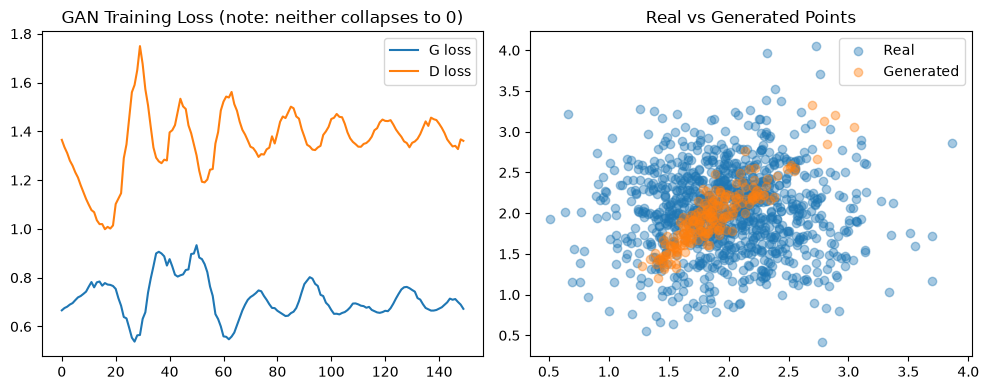

Final G loss: 0.6610  D loss: 1.3927
Real mean: [1.9957735538482666, 2.0193402767181396]  Generated mean: [1.8680000305175781, 1.9579999446868896]


In [1]:
# WHAT/WHY: train a tiny GAN on 2-D points so the adversarial loop is fully
# visible — after training, the generated cloud should sit on the real cloud.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

torch.manual_seed(0)
# ── Real data: 2-D Gaussian blob centered at (2, 2) ──────────────────────
real_data = torch.randn(1000, 2) * 0.5 + torch.tensor([2.0, 2.0])

# ── Tiny generator and discriminator ──────────────────────────────────────
latent_dim = 8
Generator = nn.Sequential(
    nn.Linear(latent_dim, 16), nn.ReLU(),
    nn.Linear(16, 2),
)
Discriminator = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 1), nn.Sigmoid(),
)
opt_G = optim.Adam(Generator.parameters(),     lr=1e-3)
opt_D = optim.Adam(Discriminator.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# ── Adversarial loop: alternate D step and G step every iteration ─────────
g_losses, d_losses = [], []
batch_size = 64
for epoch in range(1500):  # tiny networks — 1500 iterations run in seconds
    # D step: real → 1, detached fakes → 0
    idx  = torch.randint(0, len(real_data), (batch_size,))
    real = real_data[idx]
    fake = Generator(torch.randn(batch_size, latent_dim)).detach()
    loss_D = criterion(Discriminator(real), torch.ones(batch_size, 1)) + \
             criterion(Discriminator(fake), torch.zeros(batch_size, 1))
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()
    # G step: make D call fresh fakes "real"
    fake   = Generator(torch.randn(batch_size, latent_dim))
    loss_G = criterion(Discriminator(fake), torch.ones(batch_size, 1))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    g_losses.append(loss_G.item()); d_losses.append(loss_D.item())

# ── Plot loss curves + real vs generated points ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(g_losses[::10], label='G loss'); axes[0].plot(d_losses[::10], label='D loss')
axes[0].set_title('GAN Training Loss (note: neither collapses to 0)'); axes[0].legend()
with torch.no_grad():
    fake_pts = Generator(torch.randn(200, latent_dim)).numpy()
axes[1].scatter(real_data[:, 0], real_data[:, 1], alpha=0.4, label='Real')
axes[1].scatter(fake_pts[:, 0],  fake_pts[:, 1],  alpha=0.4, label='Generated')
axes[1].set_title('Real vs Generated Points'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Final G loss: {g_losses[-1]:.4f}  D loss: {d_losses[-1]:.4f}')
print(f'Real mean: {real_data.mean(0).tolist()}  Generated mean: {fake_pts.mean(0).round(3).tolist()}')


## Part 2 — 🌍 Real-World Worked Example: GAN Generating Handwritten Digits

**Industry context:**
- GANs generate synthetic training data for autonomous-vehicle datasets
- Pharmaceutical research uses GANs to propose molecular structures
- Design teams use GAN-generated imagery for rapid mockups

Same loop as Part 1, scaled to images. This is a small **fully-connected GAN** (a real DCGAN uses convolutional layers — see references). We train 5 quick CPU epochs for classroom speed, so expect *blurry but digit-like* samples.


Epoch 1/5 — D_loss=0.8774  G_loss=1.4142


Epoch 2/5 — D_loss=0.6754  G_loss=2.3134


Epoch 3/5 — D_loss=0.6331  G_loss=2.4956


Epoch 4/5 — D_loss=0.5972  G_loss=2.5694


Epoch 5/5 — D_loss=0.5101  G_loss=2.8917


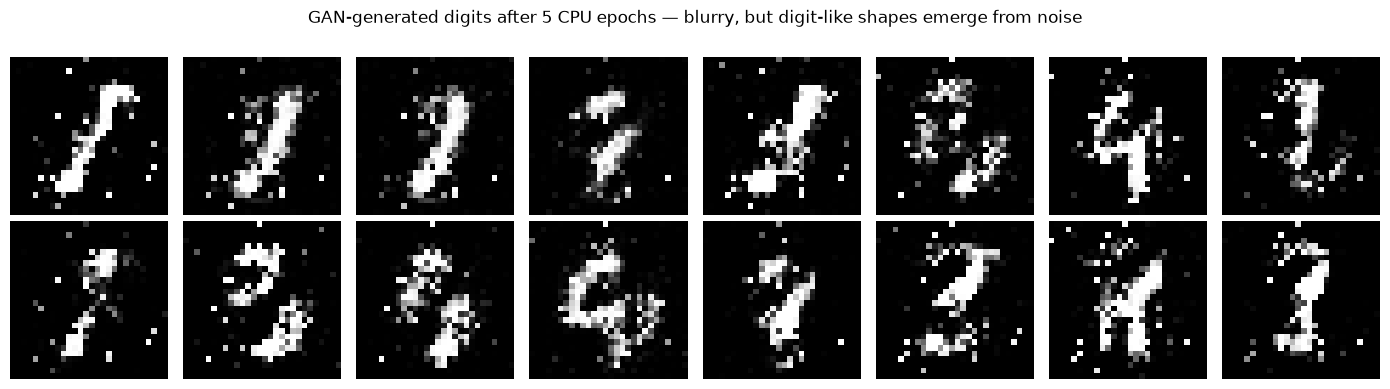

Longer training (20+ epochs) and convolutional layers (DCGAN) sharpen these a lot — try it.


In [2]:
# WHAT/WHY: the exact adversarial loop from Part 1, applied to MNIST images.
# The generated-sample figure at the end is the deliverable: digits from noise.
import torchvision, torchvision.transforms as T

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Data scaled to [-1, 1] to match the generator's Tanh output ───────────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
loader    = torch.utils.data.DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ── Generator: noise (64) → flattened 28×28 image ─────────────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: flattened image → probability real ─────────────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
EPOCHS = 5  # ~25 s on CPU; raise for sharper samples
for epoch in range(EPOCHS):
    epoch_d, epoch_g = [], []
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # D step: real → 1, detached fakes → 0
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # G step: fool D with fresh fakes
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
        epoch_d.append(loss_D.item()); epoch_g.append(loss_G.item())
    d_losses.append(sum(epoch_d)/len(epoch_d))
    g_losses.append(sum(epoch_g)/len(epoch_g))
    print(f"Epoch {epoch+1}/{EPOCHS} — D_loss={d_losses[-1]:.4f}  G_loss={g_losses[-1]:.4f}")

# ── Generate 16 digits from pure noise and SHOW them inline ───────────────
G.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM)
    fake_imgs = G(z).view(-1, 28, 28).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img in zip(axes.flatten(), fake_imgs):
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1); ax.axis('off')
plt.suptitle("GAN-generated digits after 5 CPU epochs — blurry, but digit-like shapes emerge from noise")
plt.tight_layout(); plt.show()
print("Longer training (20+ epochs) and convolutional layers (DCGAN) sharpen these a lot — try it.")


## 📚 References & Further Reading

**Foundational Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434) *(the convolutional upgrade of this notebook's architecture)*
- Karras et al. (2020) — [StyleGAN2](https://arxiv.org/abs/1912.04958)

**Next in this unit:** conditional GANs (06), StyleGAN ideas (07), training stabilization (08)


## 📝 Summary

In **05 — Building and Training a Simple GAN** you implemented the full adversarial loop — D step (real=1, detached fakes=0), G step (fool D) — watched a 2-D generator move its cloud onto the real distribution, and generated MNIST digits from pure noise (both figures are in this notebook's outputs). You also learned what healthy loss curves look like and why `.detach()` is required in the D step. Example 06 adds label control; example 08 fixes this loop when it breaks.
